## Example of Simple Moving Averages

YF.download() has changed argument auto_adjust default to True


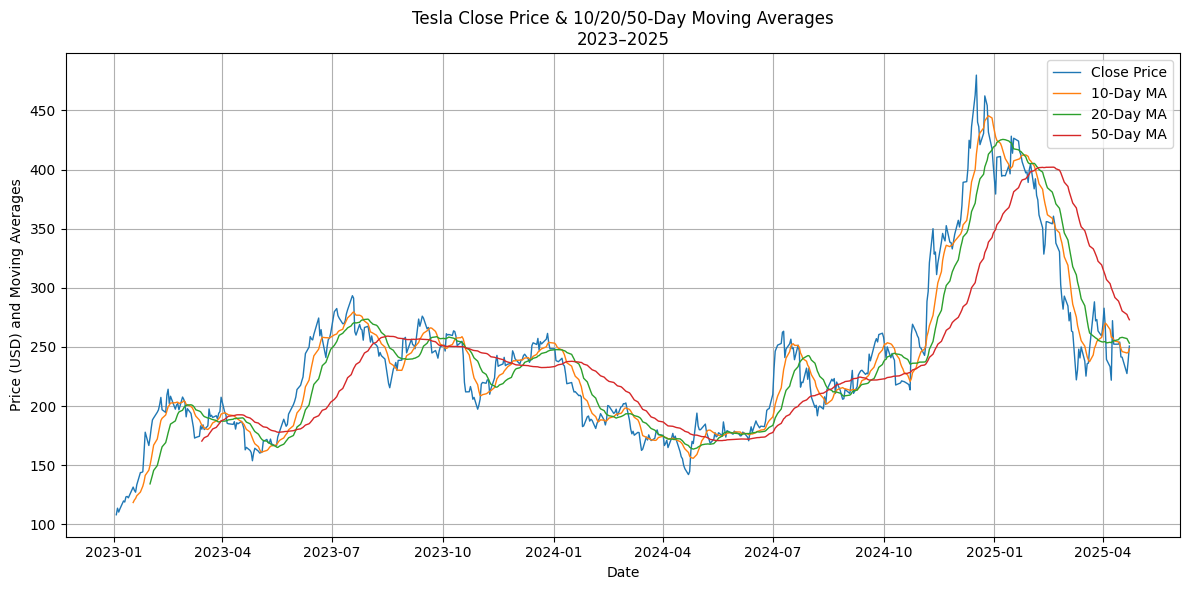

In [1]:
# 1) IMPORT LIBRARIES
import yfinance as yf               # yfinance to fetch historical market data
import pandas as pd                # pandas for data manipulation (DataFrame)
import matplotlib.pyplot as plt    # matplotlib for plotting

# 2) DOWNLOAD TESLA (TSLA) DATA
#    - 'start' is the first date (inclusive)
#    - 'end' is the last date (exclusive)
tesla = yf.download(
    tickers='TSLA', 
    start='2023-01-01', 
    end='2025-04-24', 
    progress=False                # disable download progress bar
)

# 3) EXTRACT CLOSE PRICE
#    We only need the 'Close' column for moving averages
close = tesla['Close']

# 4) CALCULATE MOVING AVERAGES
#    rolling(window=N).mean() computes the N-day simple moving average
ma10 = close.rolling(window=10).mean()   # 10-day MA
ma20 = close.rolling(window=20).mean()   # 20-day MA
ma50 = close.rolling(window=50).mean()   # 50-day MA

# 5) PLOT CLOSE PRICE AND MOVING AVERAGES
plt.figure(figsize=(12, 6))              # set figure size

# Plot the raw close price
plt.plot(close.index, close, label='Close Price', linewidth=1)

# Plot each moving average
plt.plot(ma10.index, ma10, label='10-Day MA', linewidth=1)
plt.plot(ma20.index, ma20, label='20-Day MA', linewidth=1)
plt.plot(ma50.index, ma50, label='50-Day MA', linewidth=1)

# 6) FORMAT THE PLOT
plt.title('Tesla Close Price & 10/20/50-Day Moving Averages\n2023–2025')  # title
plt.xlabel('Date')                        # x-axis label
plt.ylabel('Price (USD) and Moving Averages')                  # y-axis label
plt.legend()                              # show legend
plt.grid(True)                            # add grid for readability

# 7) DISPLAY THE PLOT
plt.tight_layout()                        # adjust padding
plt.show()                                # render the plot


## Example of Simple Moving Average, Exponential Moving Average and Linearly Weighted Moving Average

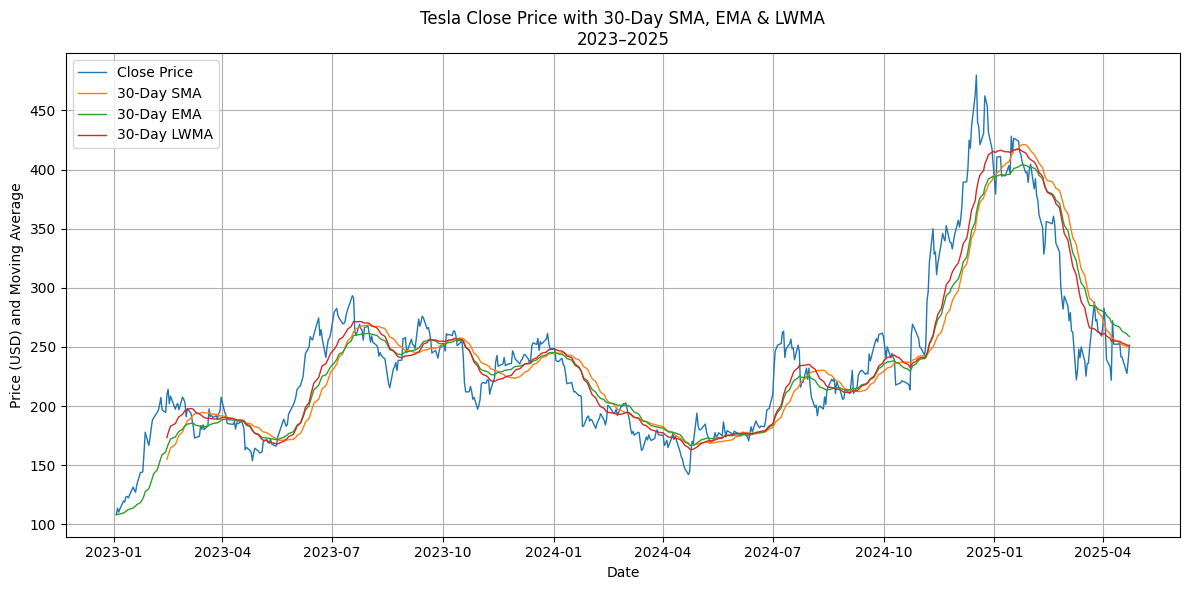

In [2]:
# 1) IMPORT LIBRARIES
import yfinance as yf               # yfinance to fetch historical market data
import pandas as pd                # pandas for data manipulation (DataFrame)
import numpy as np                 # numpy for numerical operations (weights)
import matplotlib.pyplot as plt    # matplotlib for static plotting

# 2) DOWNLOAD TESLA (TSLA) DATA
#    - 'start' is inclusive, 'end' is exclusive
tesla = yf.download(
    tickers='TSLA', 
    start='2023-01-01', 
    end='2025-04-25', 
    progress=False                # disable the progress bar
)

# 3) EXTRACT CLOSE PRICE SERIES
close = tesla['Close']             # get only the 'Close' column

# 4) CALCULATE 30-DAY SIMPLE MOVING AVERAGE (SMA)
sma15 = close.rolling(window=30).mean()  

# 5) CALCULATE 30-DAY EXPONENTIAL MOVING AVERAGE (EMA)
#    - span=30 sets the decay so that the effective window ≈30 days
ema30 = close.ewm(span=30, adjust=False).mean()  

# 6) CALCULATE 30-DAY LINEARLY WEIGHTED MOVING AVERAGE (LWMA)
#    - weights 1,2,…,30 so the most recent day gets weight 30
weights = np.arange(1, 31)                                          
lwma30 = close.rolling(window=30).apply(
    lambda prices: np.dot(prices, weights) / weights.sum(), raw=True
)

# 7) PLOT CLOSE PRICE AND ALL THREE MOVING AVERAGES
plt.figure(figsize=(12, 6))           # set figure size

plt.plot(close.index, close, label='Close Price', linewidth=1)  
plt.plot(sma15.index, sma15, label='30-Day SMA', linewidth=1)   
plt.plot(ema30.index, ema30, label='30-Day EMA', linewidth=1)   
plt.plot(lwma30.index, lwma30, label='30-Day LWMA', linewidth=1) 

# 8) FORMAT THE PLOT
plt.title('Tesla Close Price with 30-Day SMA, EMA & LWMA\n2023–2025')  
plt.xlabel('Date')                   # x-axis label
plt.ylabel('Price (USD) and Moving Average')             # y-axis label
plt.legend()                         # show legend
plt.grid(True)                       # add grid lines for readability
plt.tight_layout()                   # adjust layout margins

# 9) DISPLAY THE PLOT
plt.show()                           # render the plot window (or inline in notebook)


## Example of Triangle Moving Average and Simple Moving Average

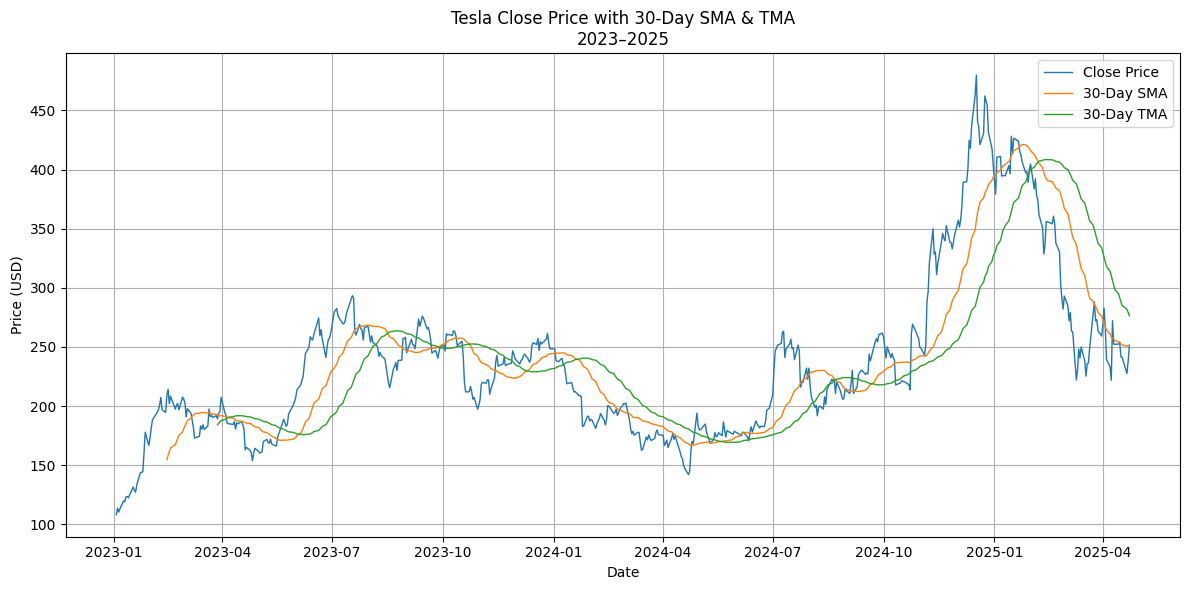

In [3]:
# 1) IMPORT LIBRARIES
import yfinance as yf               # to fetch historical stock data
import pandas as pd                # for DataFrame & rolling calculations
import matplotlib.pyplot as plt    # for plotting

# 2) DOWNLOAD TESLA (TSLA) DATA
#    - 'start' is inclusive, 'end' is exclusive
tesla = yf.download(
    tickers='TSLA',
    start='2023-01-01',
    end='2025-04-25',
    progress=False
)

# 3) EXTRACT CLOSE PRICE SERIES
close = tesla['Close']

# 4) CALCULATE 30-DAY SIMPLE MOVING AVERAGE (SMA)
sma15 = close.rolling(window=30).mean()

# 5) CALCULATE 30-DAY TRIANGULAR MOVING AVERAGE (TMA)
#    TMA = SMA of the SMA
tma30 = sma15.rolling(window=30).mean()

# 6) PLOT CLOSE, SMA AND TMA
plt.figure(figsize=(12, 6))

# raw close price
plt.plot(close.index, close, label='Close Price', linewidth=1)

# 30-day SMA
plt.plot(sma15.index, sma15, label='30-Day SMA', linewidth=1)

# 30-day TMA
plt.plot(tma30.index, tma30, label='30-Day TMA', linewidth=1)

# 7) FORMAT THE PLOT
plt.title('Tesla Close Price with 30-Day SMA & TMA\n2023–2025')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 8) DISPLAY THE PLOT
plt.show()


## Triple Moving Average Crossover Strategy

C:\Users\Trial\AppData\Local\Temp\ipykernel_22896\2505820933.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[ long_zone & ~long_zone.shift(1).fillna(False), 'signal'] =  1
C:\Users\Trial\AppData\Local\Temp\ipykernel_22896\2505820933.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[short_zone & ~short_zone.shift(1).fillna(False), 'signal'] = -1


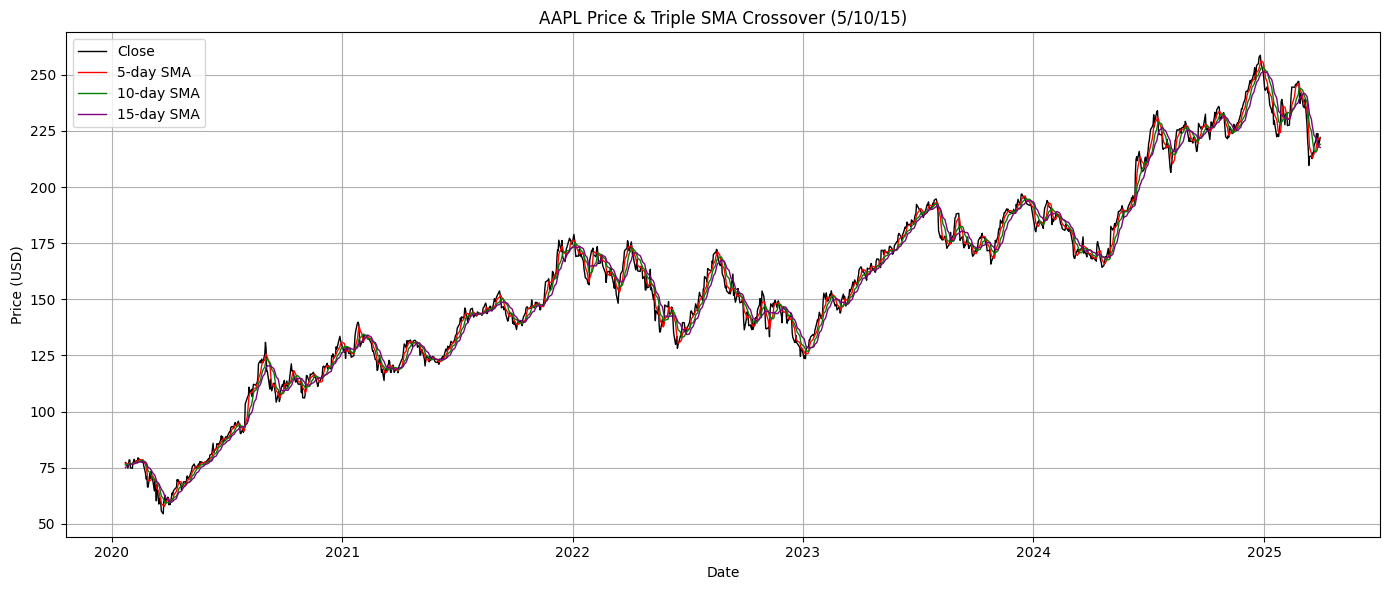

In [4]:
# 1) IMPORT LIBRARIES
import yfinance as yf               # to fetch historical market data
import pandas as pd                # for DataFrame operations
import matplotlib.pyplot as plt    # for plotting

# 2) DOWNLOAD Apple DATA AND BUILD INITIAL DF
#    We directly assign the downloaded DataFrame to `df`
df = yf.download(
    tickers='AAPL',
    start='2020-01-01',
    end='2025-04-01',
    progress=False
)

# 3) KEEP ONLY CLOSE PRICE
df = df[['Close']].rename(columns={'Close':'close'})  
#    Now df has one column: 'close'

# 4) CALCULATE MOVING AVERAGES IN-PLACE
df['sma5'] = df['close'].rolling(window=5).mean()   # fast
df['sma10'] = df['close'].rolling(window=10).mean()   # medium
df['sma15'] = df['close'].rolling(window=15).mean()   # slow
df = df.dropna()

# GENERATE ENTRY/EXIT SIGNALS
df['signal'] = 0
#  fast > med & fast > slow → potential buy zone
long_zone  = (df['sma5'] > df['sma10']) & (df['sma5'] > df['sma15']) & (df['sma10'] > df['sma15'])
#  fast < med & fast < slow → potential sell zone
short_zone = (df['sma5'] < df['sma10']) & (df['sma5'] < df['sma15']) & (df['sma10'] < df['sma15'])
#  when zone turns True from False → signal
df.loc[ long_zone & ~long_zone.shift(1).fillna(False), 'signal'] =  1
df.loc[short_zone & ~short_zone.shift(1).fillna(False), 'signal'] = -1

# CALCULATE RETURNS
df['market_ret']   = df['close'].pct_change()                # daily market return
df['strategy_ret'] = df['signal'].shift(1) * df['market_ret']  # apply yesterday’s signal today

# CUMULATIVE RETURNS
df['cum_market']   = (1 + df['market_ret']).cumprod()
df['cum_strategy'] = (1 + df['strategy_ret']).cumprod()

# PLOT PRICE & SMAs
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['close'],   label='Close', color='black', linewidth=1)
plt.plot(df.index, df['sma5'],   label='5-day SMA', color='red',   linewidth=1)
plt.plot(df.index, df['sma10'],   label='10-day SMA', color='green', linewidth=1)
plt.plot(df.index, df['sma15'],   label='15-day SMA', color='purple',linewidth=1)
plt.title('AAPL Price & Triple SMA Crossover (5/10/15)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

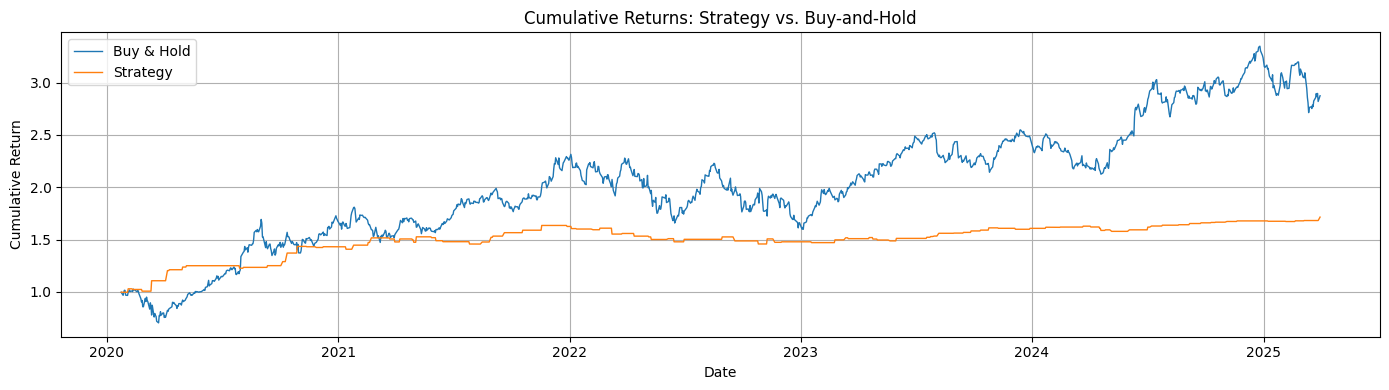

In [5]:
# PLOT CUMULATIVE RETURNS
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['cum_market'],   label='Buy & Hold', linewidth=1)
plt.plot(df.index, df['cum_strategy'], label='Strategy',    linewidth=1)
plt.title('Cumulative Returns: Strategy vs. Buy-and-Hold')
plt.xlabel('Date'); plt.ylabel('Cumulative Return')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()


In [6]:
df

Price,close,sma5,sma10,sma15,signal,market_ret,strategy_ret,cum_market,cum_strategy
Ticker,AAPL,,,,,,,,
Date,,,,,,,,,
2020-01-23,77.287010,76.866710,76.224402,75.013154,1,NaN,NaN,NaN,NaN
2020-01-24,77.064247,77.015358,76.434549,75.303032,0,-0.002882,-0.002882,0.997118,0.997118
2020-01-27,74.798180,76.541801,76.401141,75.488969,0,-0.029405,-0.000000,0.967798,0.997118
2020-01-28,76.914154,76.596036,76.418813,75.777719,0,0.028289,0.000000,0.995176,0.997118
2020-01-29,78.524147,76.917548,76.701106,76.196560,0,0.020932,0.000000,1.016007,0.997118
...,...,...,...,...,...,...,...,...,...
2025-03-25,223.750000,218.418002,215.893001,221.159334,0,0.013682,0.000000,2.895053,1.682277
2025-03-26,221.529999,219.676001,216.348001,220.212001,0,-0.009922,-0.000000,2.866329,1.682277


You can see that the market returns are 2.8 but the strategy returns are 1.7 with fewer spikes.